In [ ]:
print("Hello World")

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv('TRAIN-2.csv')

In [13]:
df.head(10)

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,7011.84
1,T1000002,253,S4,L2,R1,2018-01-01,1,Yes,60,51789.12
2,T1000003,252,S3,L2,R1,2018-01-01,1,Yes,42,36868.20
3,T1000004,251,S2,L3,R1,2018-01-01,1,Yes,23,19715.16
4,T1000005,250,S2,L3,R4,2018-01-01,1,Yes,62,45614.52
5,T1000006,249,S1,L3,R2,2018-01-01,1,Yes,39,34211.22
6,T1000007,248,S1,L1,R2,2018-01-01,1,Yes,40,35352.66
7,T1000008,247,S1,L1,R3,2018-01-01,1,Yes,64,52650.00
8,T1000009,246,S3,L1,R3,2018-01-01,1,Yes,62,42633.78
9,T1000010,254,S4,L1,R1,2018-01-01,1,Yes,87,62572.80


In [15]:
df.isnull().sum()

ID               0
Store_id         0
Store_Type       0
Location_Type    0
Region_Code      0
Date             0
Holiday          0
Discount         0
#Order           0
Sales            0
dtype: int64

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 188340 entries, 0 to 188339
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ID             188340 non-null  str    
 1   Store_id       188340 non-null  int64  
 2   Store_Type     188340 non-null  str    
 3   Location_Type  188340 non-null  str    
 4   Region_Code    188340 non-null  str    
 5   Date           188340 non-null  str    
 6   Holiday        188340 non-null  int64  
 7   Discount       188340 non-null  str    
 8   #Order         188340 non-null  int64  
 9   Sales          188340 non-null  float64
dtypes: float64(1), int64(3), str(6)
memory usage: 14.4 MB


In [3]:
df['Date'] = pd.to_datetime(df['Date'])  
df = df.sort_values('Date')

In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 188340 entries, 0 to 188339
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   ID             188340 non-null  str           
 1   Store_id       188340 non-null  int64         
 2   Store_Type     188340 non-null  str           
 3   Location_Type  188340 non-null  str           
 4   Region_Code    188340 non-null  str           
 5   Date           188340 non-null  datetime64[us]
 6   Holiday        188340 non-null  int64         
 7   Discount       188340 non-null  str           
 8   #Order         188340 non-null  int64         
 9   Sales          188340 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(3), str(5)
memory usage: 15.8 MB


In [29]:
df.head(5)

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,7011.84
248,T1000249,64,S3,L1,R2,2018-01-01,1,Yes,52,42293.94
247,T1000248,65,S1,L2,R2,2018-01-01,1,Yes,60,46070.64
246,T1000247,66,S3,L3,R3,2018-01-01,1,Yes,28,26151.12
245,T1000246,67,S2,L5,R1,2018-01-01,1,Yes,65,44949.45


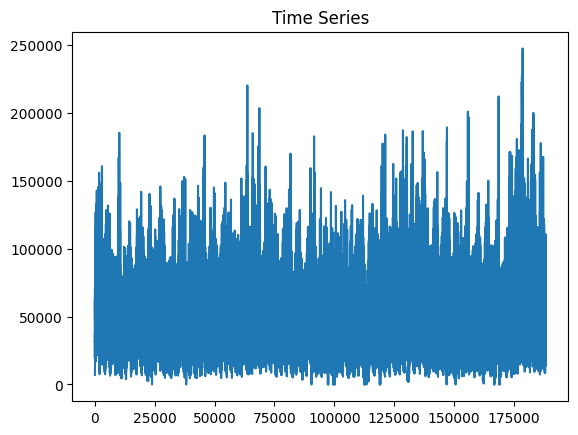

In [4]:
plt.plot(df['Sales']) 
plt.title("Time Series")
plt.show()

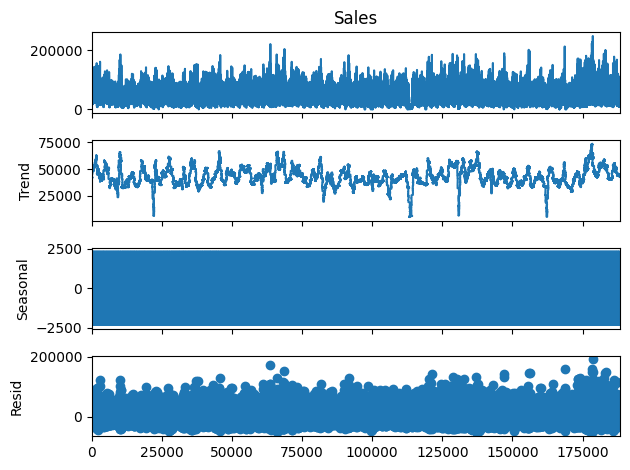

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['Sales'], model='additive', period=365)

result.plot()
plt.show()

In [7]:
daily = df.groupby('Date')['Sales'].sum().reset_index()
daily.columns = ['Date', 'Total_Sales']
daily = daily.sort_values('Date').reset_index(drop=True)

In [8]:
daily.head(10)

,Date,Total_Sales
0,2018-01-01,15345484.5
1,2018-01-02,19592415.0
2,2018-01-03,18652527.0
3,2018-01-04,19956267.0
4,2018-01-05,22902651.0
5,2018-01-06,16351956.0
6,2018-01-07,18219249.0
7,2018-01-08,15641283.0
8,2018-01-09,14197074.0
9,2018-01-10,14712108.0


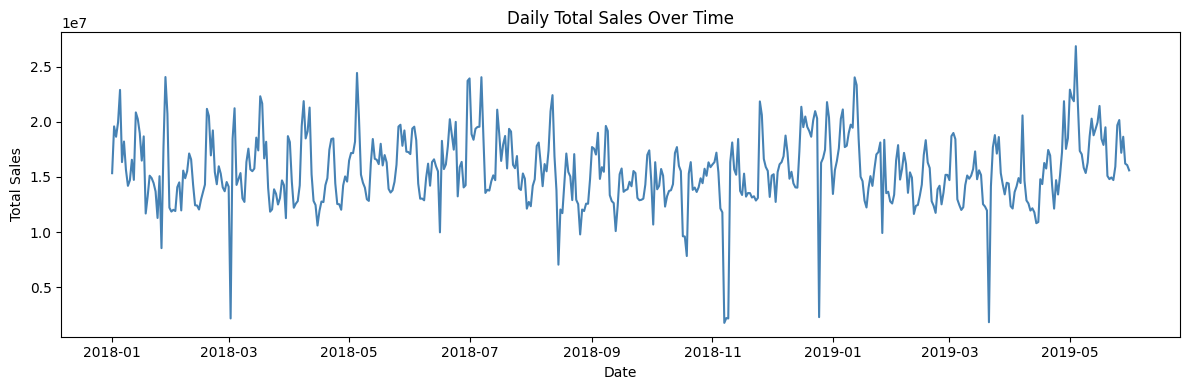

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(daily['Date'], daily['Total_Sales'], color='steelblue')
plt.title('Daily Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [10]:
daily['Trend'] = daily['Total_Sales'].rolling(window=30).mean()

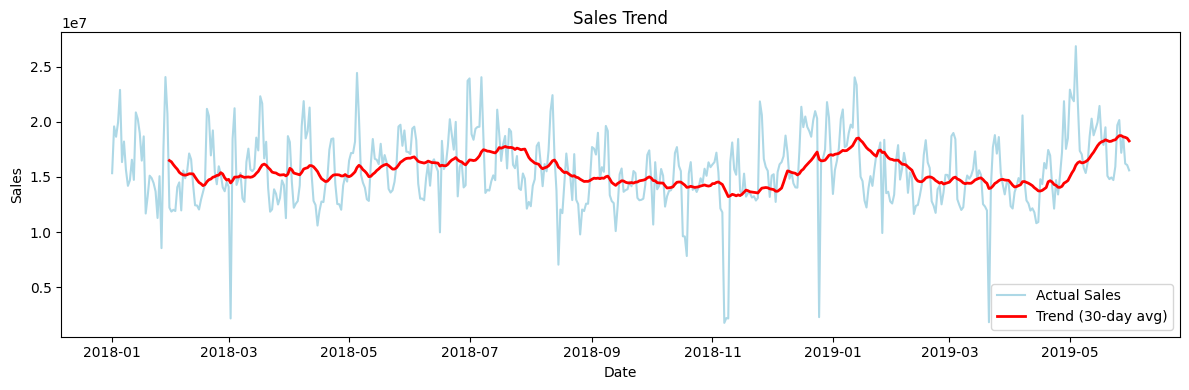

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(daily['Date'], daily['Total_Sales'], color='lightblue', label='Actual Sales')
plt.plot(daily['Date'], daily['Trend'], color='red', linewidth=2, label='Trend (30-day avg)')
plt.title('Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
daily['DayOfWeek'] = daily['Date'].dt.dayofweek
dow_avg = daily.groupby('DayOfWeek')['Total_Sales'].mean()
day_names = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']

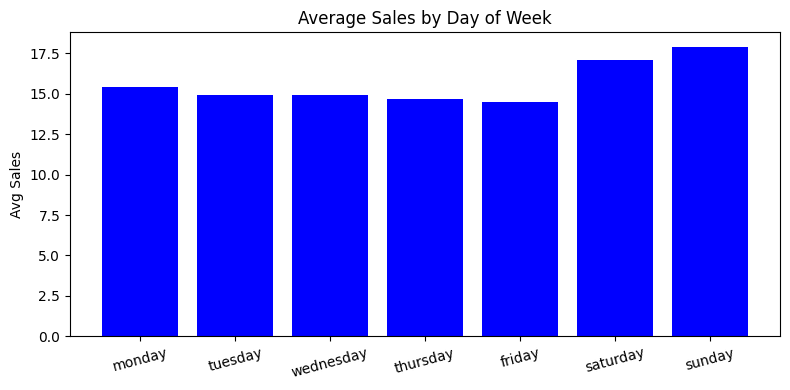

In [13]:
plt.figure(figsize=(8, 4))
plt.bar(day_names, dow_avg.values / 1e6, color='blue')
plt.title('Average Sales by Day of Week')
plt.ylabel('Avg Sales')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [14]:
daily['Seasonality'] = daily['DayOfWeek'].map(dow_avg)
daily['Noise'] = daily['Total_Sales'] - daily['Trend'] - daily['Seasonality']

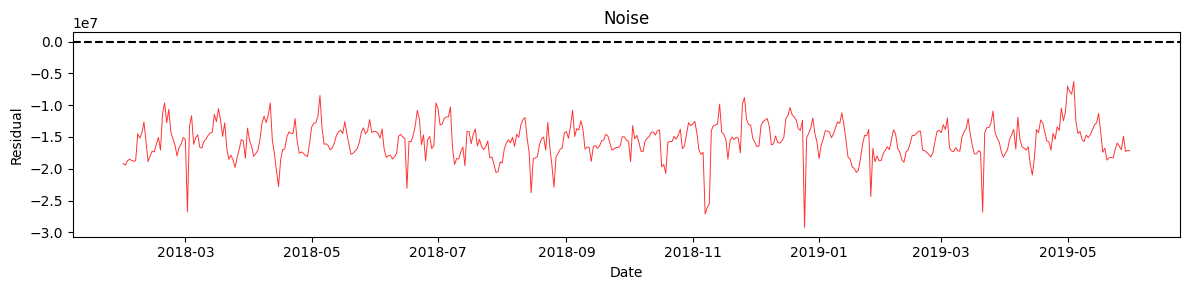

In [16]:
plt.figure(figsize=(12, 3))
plt.plot(daily['Date'], daily['Noise'], color='red', linewidth=0.7, alpha=0.8)
plt.axhline(0, linestyle='--', color='black')
plt.title('Noise')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

In [17]:
daily['Year'] = daily['Date'].dt.year         
daily['Month'] = daily['Date'].dt.month        
daily['DayOfWeek'] = daily['Date'].dt.dayofweek     
daily['DayOfMonth'] = daily['Date'].dt.day          
daily['Quarter'] = daily['Date'].dt.quarter       

daily['IsWeekend']  = (daily['DayOfWeek'] >= 5).astype(int)
daily['DayIndex']   = (daily['Date'] - daily['Date'].min()).dt.days

In [18]:
daily.head(10)

,Date,Total_Sales,Trend,DayOfWeek,Seasonality,Noise,Year,Month,DayOfMonth,Quarter,IsWeekend,DayIndex
0,2018-01-01,15345484.5,NaN,0,1.543628e+07,NaN,2018,1,1,1,0,0
1,2018-01-02,19592415.0,NaN,1,1.489308e+07,NaN,2018,1,2,1,0,1
2,2018-01-03,18652527.0,NaN,2,1.490193e+07,NaN,2018,1,3,1,0,2
3,2018-01-04,19956267.0,NaN,3,1.468467e+07,NaN,2018,1,4,1,0,3
4,2018-01-05,22902651.0,NaN,4,1.449087e+07,NaN,2018,1,5,1,0,4
5,2018-01-06,16351956.0,NaN,5,1.705638e+07,NaN,2018,1,6,1,1,5
6,2018-01-07,18219249.0,NaN,6,1.790108e+07,NaN,2018,1,7,1,1,6
7,2018-01-08,15641283.0,NaN,0,1.543628e+07,NaN,2018,1,8,1,0,7
8,2018-01-09,14197074.0,NaN,1,1.489308e+07,NaN,2018,1,9,1,0,8
9,2018-01-10,14712108.0,NaN,2,1.490193e+07,NaN,2018,1,10,1,0,9


In [19]:
daily['Lag_1'] = daily['Total_Sales'].shift(1)   
daily['Lag_7'] = daily['Total_Sales'].shift(7)   
daily['Lag_14'] = daily['Total_Sales'].shift(14)  


In [20]:
daily.head(10)

,Date,Total_Sales,Trend,DayOfWeek,Seasonality,Noise,Year,Month,DayOfMonth,Quarter,IsWeekend,DayIndex,Lag_1,Lag_7,Lag_14
0,2018-01-01,15345484.5,NaN,0,1.543628e+07,NaN,2018,1,1,1,0,0,NaN,NaN,NaN
1,2018-01-02,19592415.0,NaN,1,1.489308e+07,NaN,2018,1,2,1,0,1,15345484.5,NaN,NaN
2,2018-01-03,18652527.0,NaN,2,1.490193e+07,NaN,2018,1,3,1,0,2,19592415.0,NaN,NaN
3,2018-01-04,19956267.0,NaN,3,1.468467e+07,NaN,2018,1,4,1,0,3,18652527.0,NaN,NaN
4,2018-01-05,22902651.0,NaN,4,1.449087e+07,NaN,2018,1,5,1,0,4,19956267.0,NaN,NaN
5,2018-01-06,16351956.0,NaN,5,1.705638e+07,NaN,2018,1,6,1,1,5,22902651.0,NaN,NaN
6,2018-01-07,18219249.0,NaN,6,1.790108e+07,NaN,2018,1,7,1,1,6,16351956.0,NaN,NaN
7,2018-01-08,15641283.0,NaN,0,1.543628e+07,NaN,2018,1,8,1,0,7,18219249.0,15345484.5,NaN
8,2018-01-09,14197074.0,NaN,1,1.489308e+07,NaN,2018,1,9,1,0,8,15641283.0,19592415.0,NaN
9,2018-01-10,14712108.0,NaN,2,1.490193e+07,NaN,2018,1,10,1,0,9,14197074.0,18652527.0,NaN


In [21]:
daily['Rolling_7']  = daily['Total_Sales'].rolling(window=7).mean()
daily['Rolling_30'] = daily['Total_Sales'].rolling(window=30).mean()

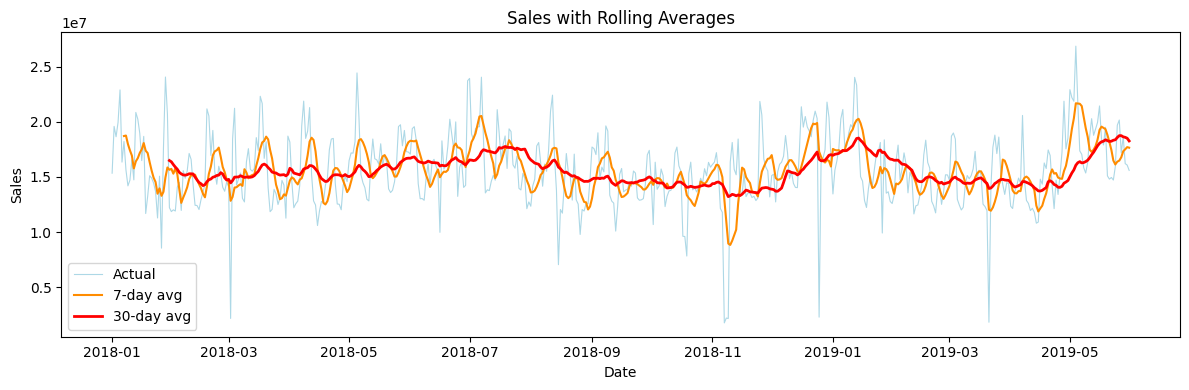

In [22]:
plt.figure(figsize=(12, 4))
plt.plot(daily['Date'], daily['Total_Sales'], color='lightblue', linewidth=0.8, label='Actual')
plt.plot(daily['Date'], daily['Rolling_7'], color='darkorange', linewidth=1.5, label='7-day avg')
plt.plot(daily['Date'], daily['Rolling_30'], color='red', linewidth=2, label='30-day avg')
plt.title('Sales with Rolling Averages')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
model_df = daily.dropna().copy()

In [25]:
model_df.head(5)

,Date,Total_Sales,Trend,DayOfWeek,Seasonality,Noise,Year,Month,DayOfMonth,Quarter,IsWeekend,DayIndex,Lag_1,Lag_7,Lag_14,Rolling_7,Rolling_30
29,2018-01-30,12217641.00,1.649352e+07,1,1.489308e+07,-1.916896e+07,2018,1,30,1,0,29,20720280.00,13687812.00,16488294.0,1.565483e+07,1.649352e+07
30,2018-01-31,11860150.89,1.637735e+07,2,1.490193e+07,-1.941912e+07,2018,1,31,1,0,30,12217641.00,11282559.00,18685467.0,1.573735e+07,1.637735e+07
31,2018-02-01,12023721.00,1.612506e+07,3,1.468467e+07,-1.878601e+07,2018,2,1,1,0,31,11860150.89,15071184.00,11687088.0,1.530199e+07,1.612506e+07
32,2018-02-02,11912538.00,1.590039e+07,4,1.449087e+07,-1.847872e+07,2018,2,2,1,0,32,12023721.00,8544637.14,13250172.0,1.578312e+07,1.590039e+07
33,2018-02-03,14075436.00,1.570436e+07,5,1.705638e+07,-1.868530e+07,2018,2,3,1,1,33,11912538.00,17676906.00,15118365.0,1.526863e+07,1.570436e+07


In [26]:
features = ['DayIndex', 'Year', 'Month', 'DayOfWeek','DayOfMonth', 'Quarter', 'IsWeekend','Lag_1', 'Lag_7', 'Lag_14','Rolling_7', 'Rolling_30']
X = model_df[features] 
y = model_df['Total_Sales']  

In [27]:
split = len(model_df) - 60

X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]
dates_test = model_df['Date'].iloc[split:]

In [28]:
lr = LinearRegression()
lr.fit(X_train, y_train)         
lr_pred = lr.predict(X_test)     

In [ ]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2  = r2_score(y_test, lr_pred)

print('Mae :', lr_mae)
print('R2 :', lr_r2)

mae : 1635153.9255412903
r2 : 0.5673847146811771


In [31]:
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [ ]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_r2  = r2_score(y_test, dt_pred)

print('Mae:',dt_mae)
print('R²:',dt_r2)

mae: 2557669.6516913814
R²: -0.5124686519825847


In [33]:
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [34]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2  = r2_score(y_test, rf_pred)

print('MAE :', rf_mae)
print('R²  :', rf_r2)

MAE : 1830163.306946792
R²  : 0.472158561509162


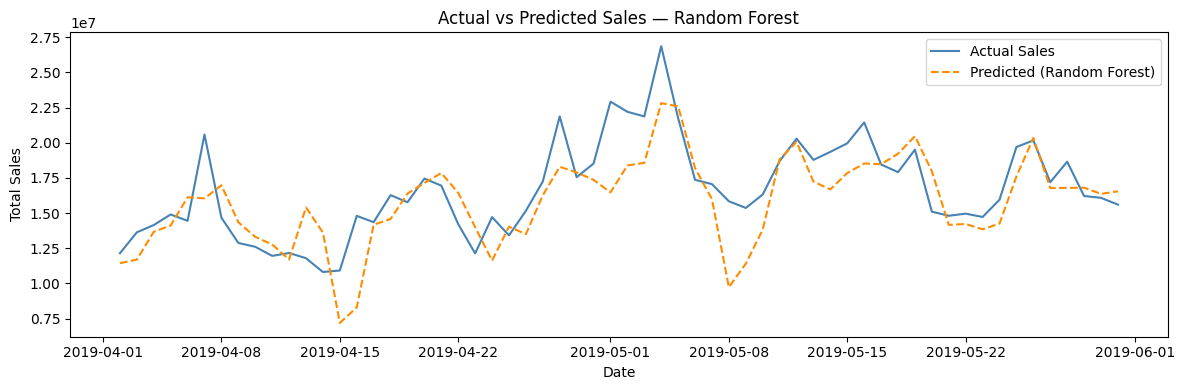

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(dates_test.values, y_test.values, color='steelblue', linewidth=1.5, label='Actual Sales')
plt.plot(dates_test.values, rf_pred, color='darkorange', linewidth=1.5, linestyle='--', label='Predicted (Random Forest)')
plt.title('Actual vs Predicted Sales — Random Forest')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.show()

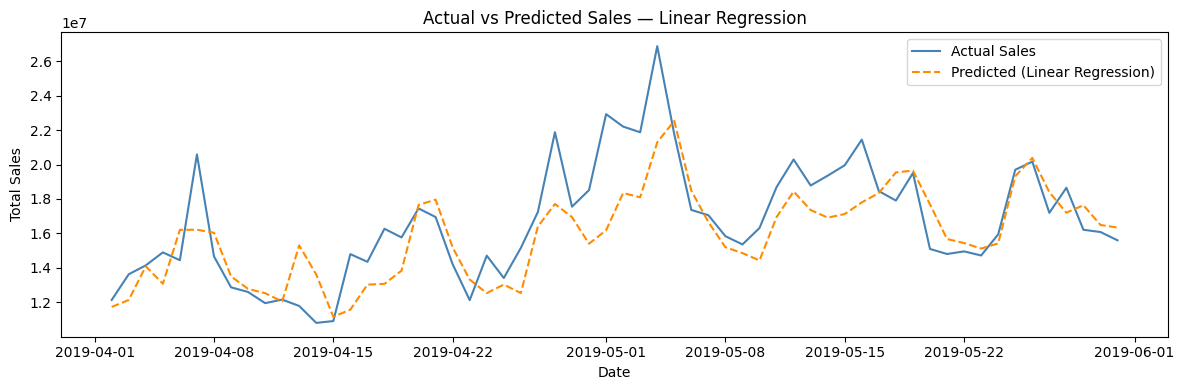

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(dates_test.values, y_test.values, color='steelblue', linewidth=1.5, label='Actual Sales')
plt.plot(dates_test.values, lr_pred, color='darkorange', linewidth=1.5, linestyle='--', label='Predicted (Linear Regression)')
plt.title('Actual vs Predicted Sales — Linear Regression')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.show()

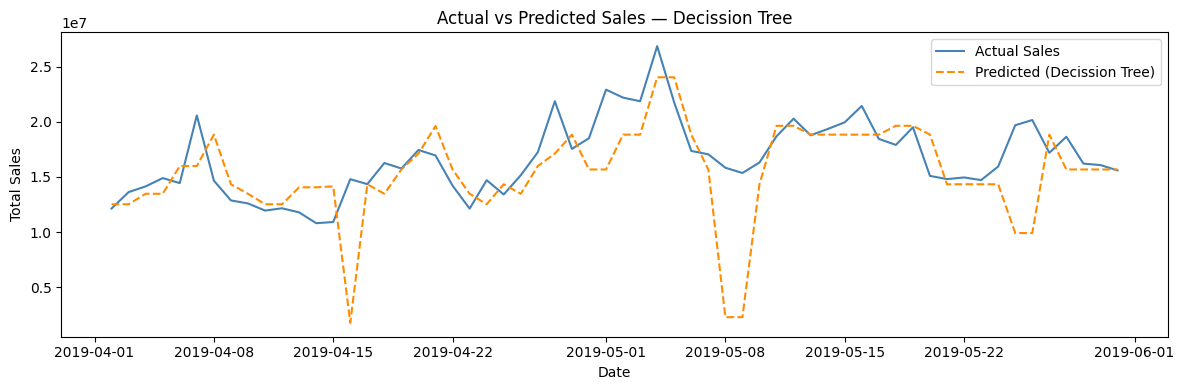

In [38]:
plt.figure(figsize=(12, 4))
plt.plot(dates_test.values, y_test.values, color='steelblue', linewidth=1.5, label='Actual Sales')
plt.plot(dates_test.values, dt_pred, color='darkorange', linewidth=1.5, linestyle='--', label='Predicted (Decission Tree)')
plt.title('Actual vs Predicted Sales — Decission Tree')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.show()

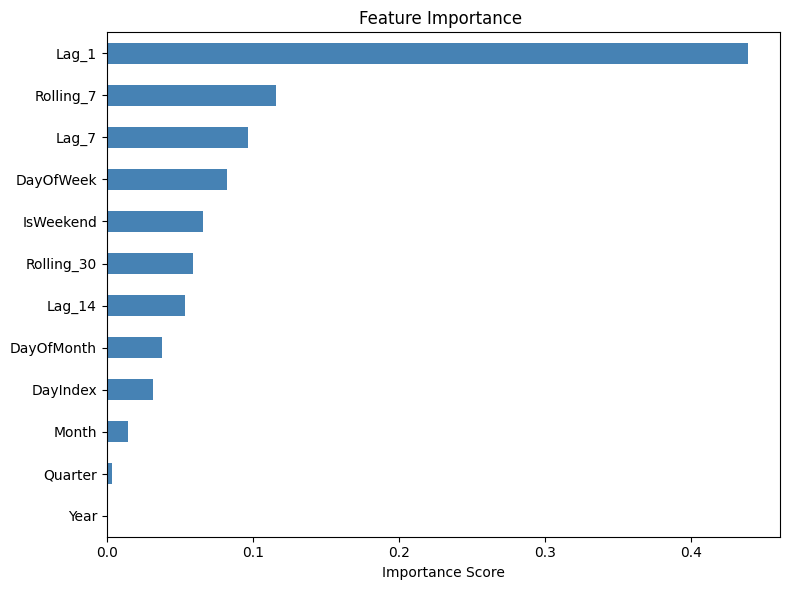

In [40]:
importance = pd.Series(rf.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 6))
importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance ')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()